# 22.2) inicialização


2 atributos, m no eixo x e outro no eixo y

centroide colocado, para depois achar o número de clusters para descobrir. 

distância para fazer a categorização dos dados. 

Calculando o centro dos pontos de cada centroide. 


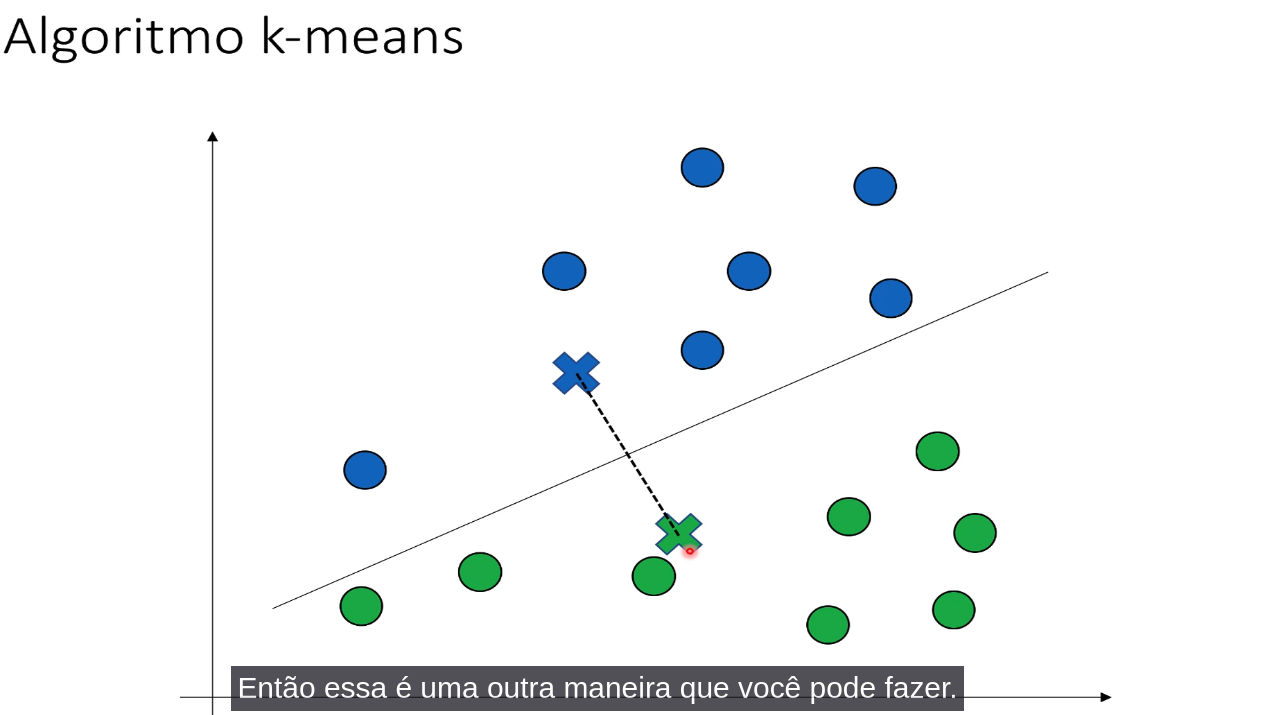


Agrupamento visual, outra maneira além da distância euclidiana


3 clusters, com 3 grupos


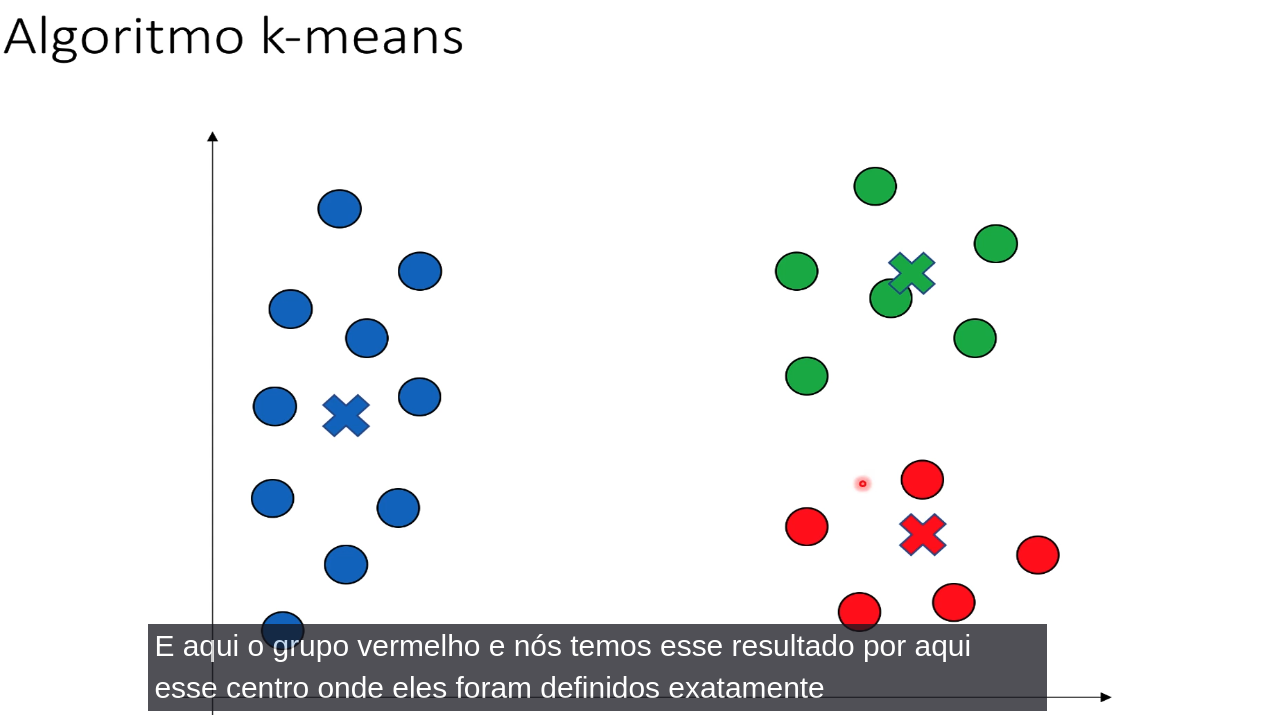

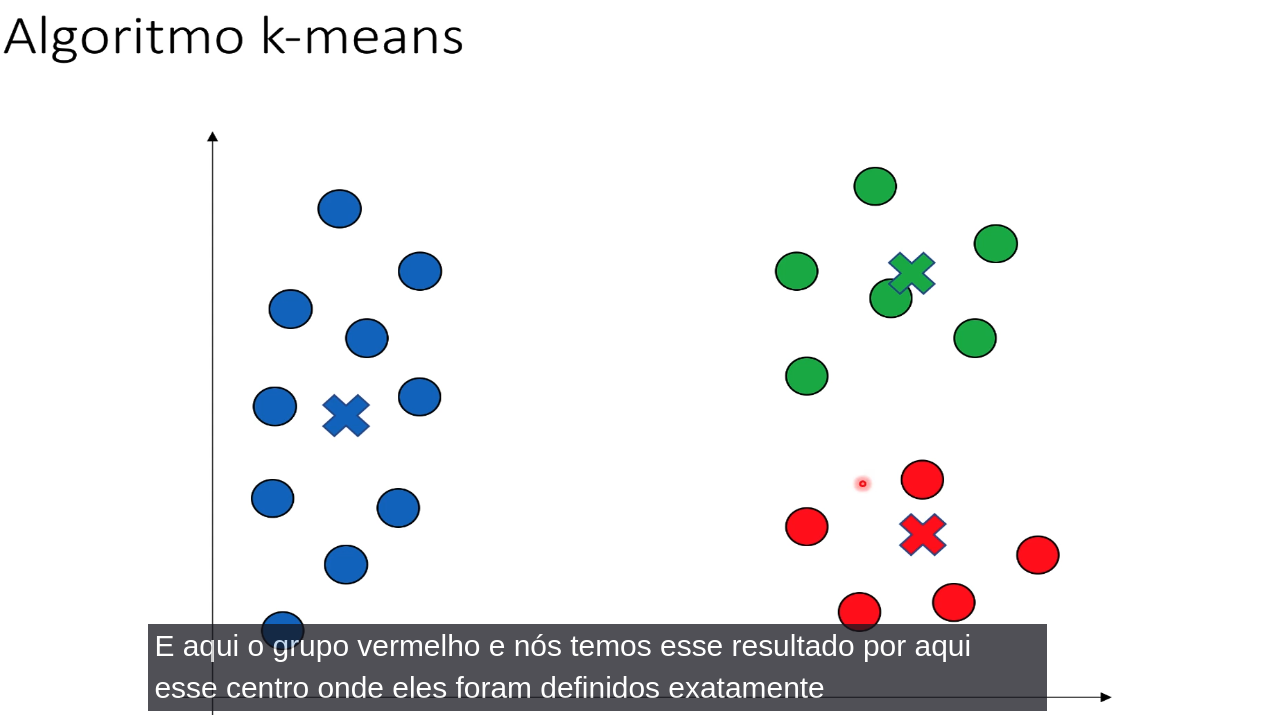

Outra inicialização do centroide, que faz diferença nos grupos

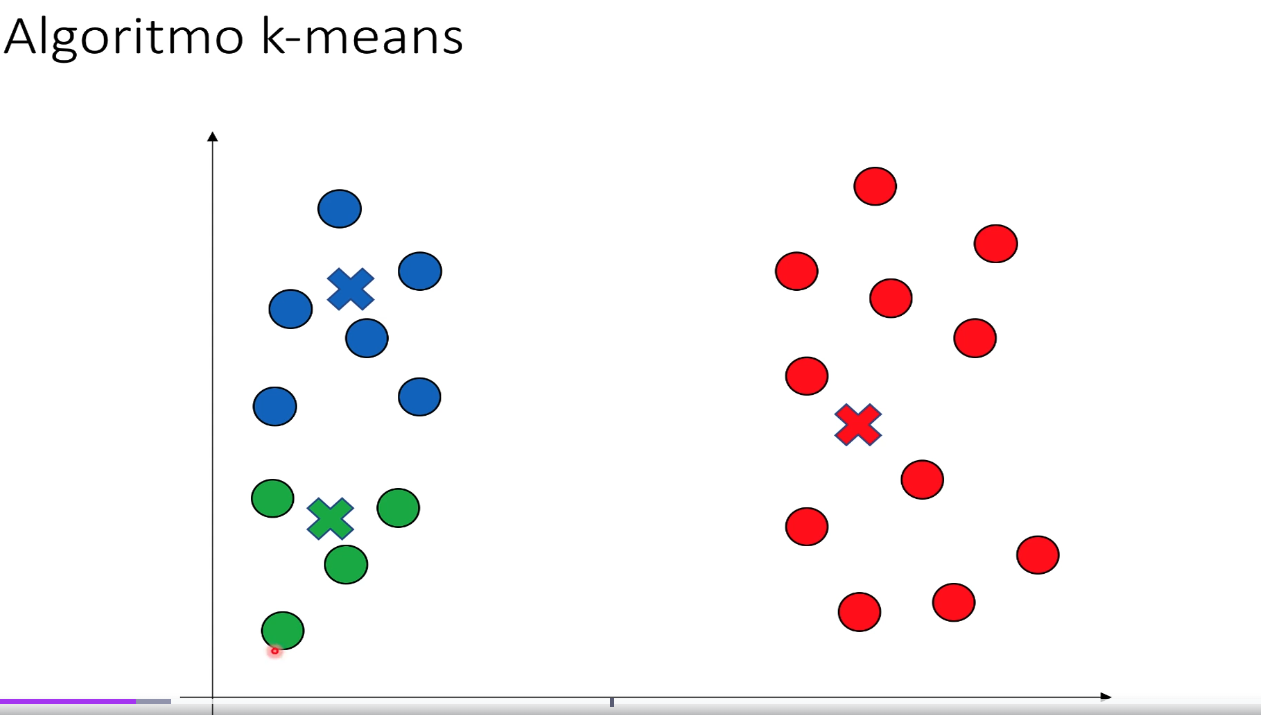



### Tem que ter cuidado para não escolher os pontos errados:


algoritmo k_means ++ resolverá o problema da inicialização dos centroides, para não dar erro:


evitar escolher pontos iniciais que vão gerar clusters ruins.




### K-means ++

1) Reduz a probabilidade de inicializações ruins

2) Seleciona os centroides iniciais que estão longes uns dos outros

e não os pontos mais próximos.


3) O primeiro centroide é selecionado randomicamente, porém, os outros são selecionados baseado na distância para o primeiro ponto.


_Outro centroide longe e onde esteja concentrado outro aglomerado de dados._


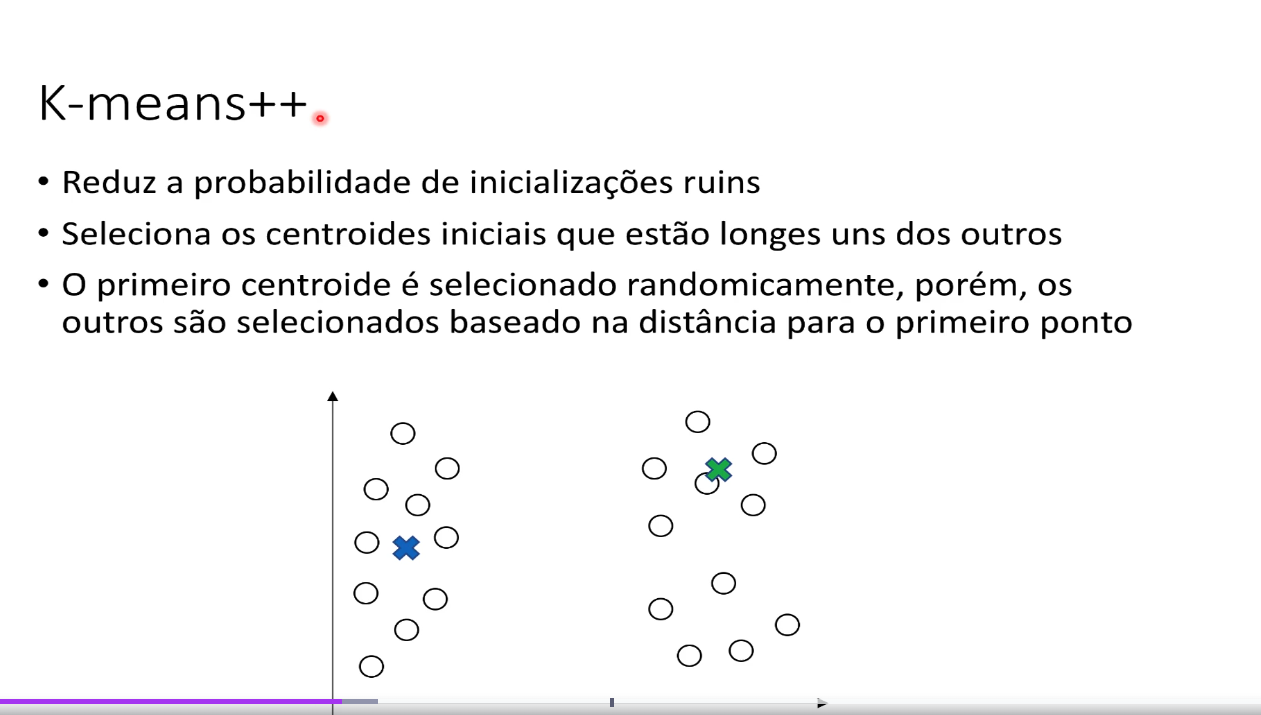


### Necessário definir os números dos clusters



Definição do número de clusters

#### 1- Ter um conhecimento prévio de quantos grupos são necessários

exemplo de bons pagadores e mau pagadores, exemplo de k=2

ou risco bom, médio, ruim, então seria k=3, 3 clusters ou 3 grupos. 

####  2- se não tiver conhecimento prévio 

o cálculo ideal seria clusters = raiz(N/2)

$$
Clusters = \sqrt{{N}/{2}}
$$


N = quantidade de registros


raiz quadrada (500 registros/2) = 15,8, ou seja teria que encontrar 15 clusters







####  3- Elbow method

Tenta vários valores de k

Para verificar se os dados se adaptaram bem para ver se tem 1 cluster, depois tenta 2, 3..., métrica com o melhor valor determina o número de cluster ideal. 


cluster para adequadar na base de dados.

 
####  4- Não existe garantia para encontrar o melhor conjunto de clusters.

### O WCSS (Within-Cluster Sum of Squares) é a métrica usada no K-Means para medir a variação interna dos clusters.

$$
WCSS = \sum_{k=1}^{K} \sum_{x_i \in C_k} \| x_i - \mu_k \|^2
$$

Onde:

𝐾 = número de clusters

𝐶𝑘 = conjunto de pontos no cluster 

μ𝑘 = centróide do cluster 

𝑥𝑖 = ponto de dado

# Métrica no elbow


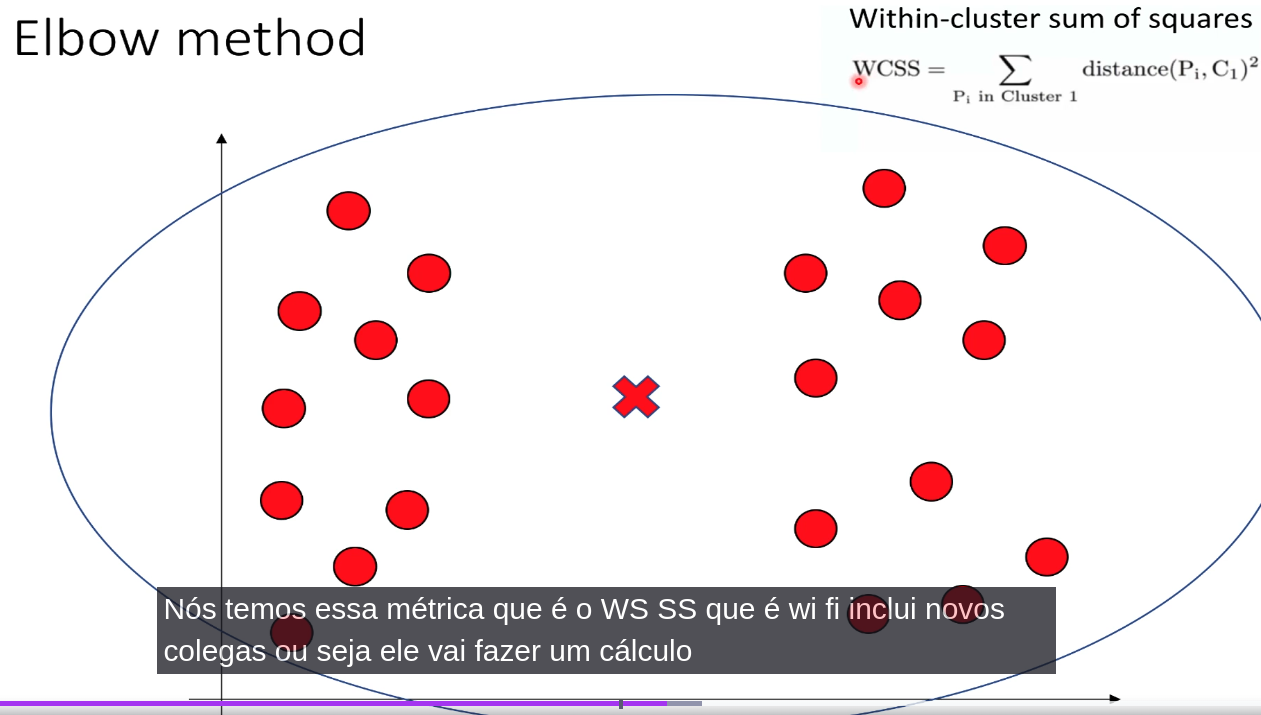


### Primeiro passo

within-cluster sum of squares  WCSS, quanto menor é a variável, melhor é a quantidade de cluster para uma determinada de dados 


cálculo da distância, percorrer os pontos dentro do circulo. 


cálculo do ponto com o centroide e eleva ao quadrado, faz com cada ponto e soma depois. 


_Valor alto do wxcss por conta da distância_




# Segunda situação do centroides


Há dois clusters

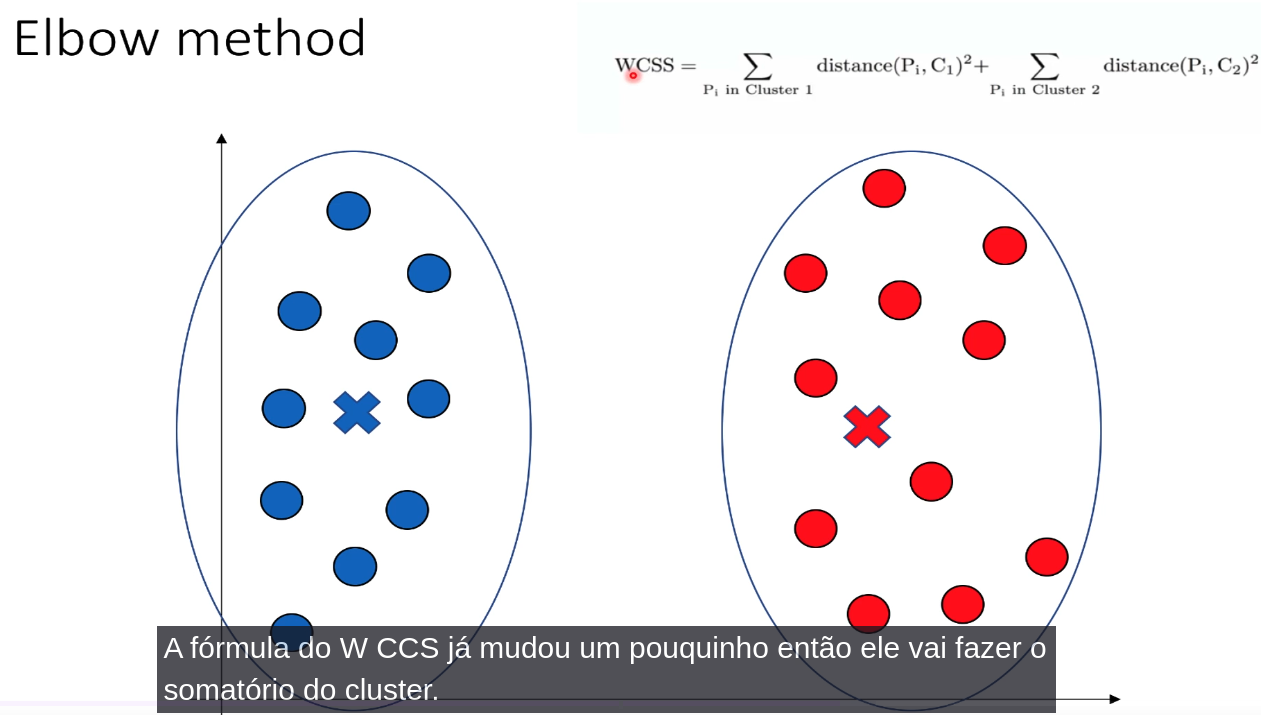



valor mais baixo do wcss, base específica pelos dois grupos, com distância dos centroides. 

#### Segundo caso ideal, com o wcss baixo




_valores pode ser zero o wcss, dependendo da quantidade dos cluster, por isso tem que ter cuidado para quantidade de cluster grandes_. 



# DECIDIR UM NÚMERO DE CLUSTER IDEAL

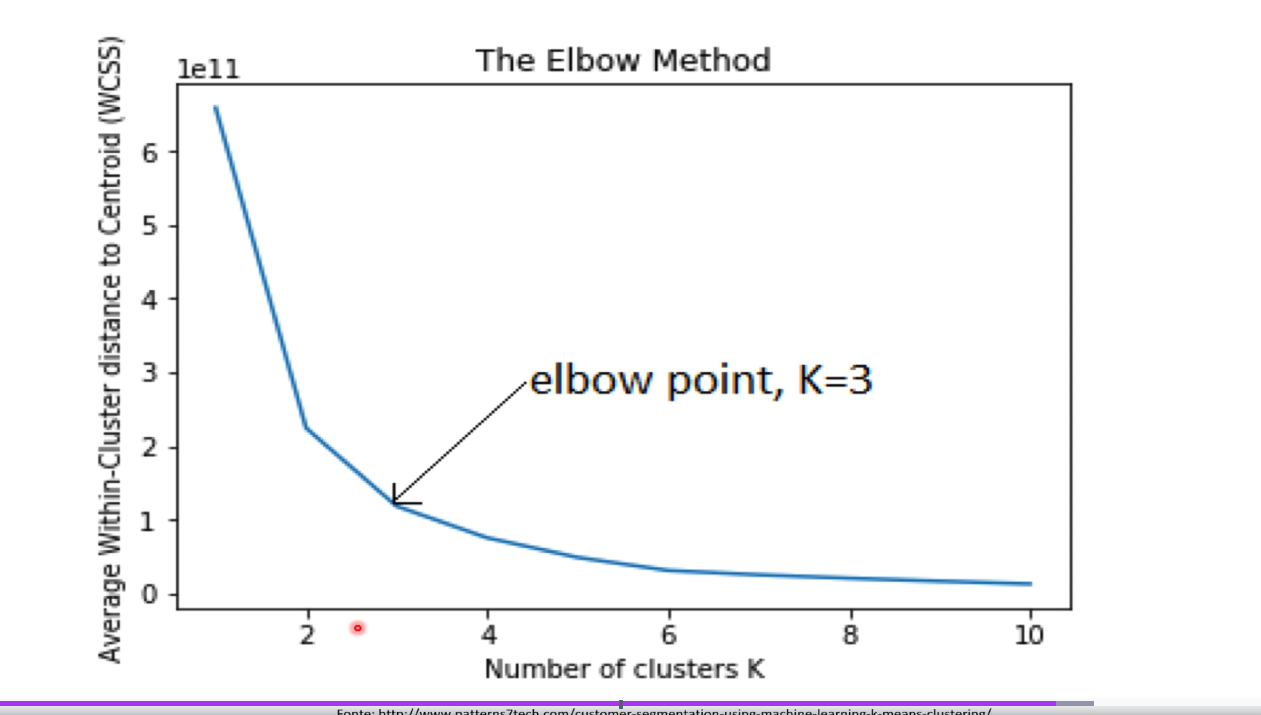

#### quanto maior o númer de cluster a média do within cluster distance to centroide fica baixo e chegando ao ponto zero praticamente 

#### pegar o ponto onde não há muita variação, sem variação grande, conforme a seta do elbow point k =3

#### precisa entender a base dos dados.


##### calcular o WCSS

In [3]:
import numpy as np
from sklearn.cluster import KMeans

# Dados de exemplo
X = np.array([[1,2],[1,4],[1,0],
              [10,2],[10,4],[10,0]])
print(X)

[[ 1  2]
 [ 1  4]
 [ 1  0]
 [10  2]
 [10  4]
 [10  0]]


In [4]:

# KMeans com 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X)

# WCSS é armazenado em inertia_
print("WCSS:", kmeans.inertia_)

WCSS: 16.0


In [5]:
# Ou implementando manualmente:

def wcss(X, labels, centroids):
    return np.sum((X - centroids[labels])**2)

# Exemplo
labels = kmeans.labels_
centroids = kmeans.cluster_centers_
print("WCSS (manual):", wcss(X, labels, centroids))

WCSS (manual): 16.0


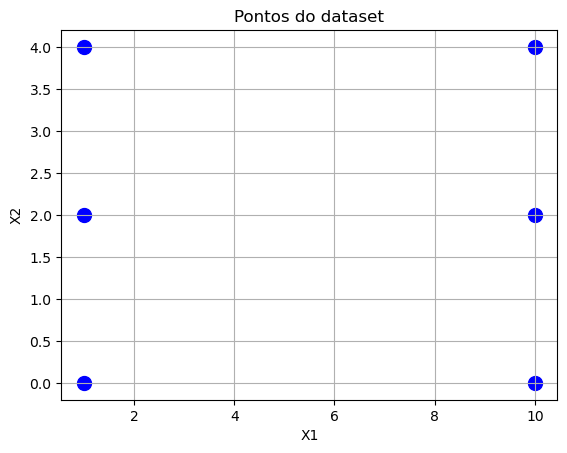

In [6]:
import matplotlib.pyplot as plt
# scatterplot
plt.scatter(X[:,0], X[:,1], c='blue', s=100, marker='o')
plt.title("Pontos do dataset")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid(True)
plt.show()